### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
# Preview first 5 rows of dataset
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
# Check dataset dimensions
data.shape

(12684, 26)

In [6]:
# Check missing values per column
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

In [9]:
# Total number of records
total = len(data)
print(total)

12684


In [10]:
# Calculate percentage of missing values in car column
car_missing_pct = (data['car'].isnull().sum() / total * 100).round(2)
print(f"Car column missing: {car_missing_pct}%")

Car column missing: 99.15%


In [11]:
# Check for duplicate rows
print(f"Duplicate rows: {data.duplicated().sum()}")

Duplicate rows: 74


In [14]:
# Before dropping, let's check how many rows 
# are affected by missing frequency values

missing_mask = data[['Bar', 'CoffeeHouse', 'CarryAway', 
                      'RestaurantLessThan20', 
                      'Restaurant20To50']].isnull().any(axis=1)

total_missing_rows = missing_mask.sum()
percentage = (total_missing_rows / len(data) * 100).round(2)

print(f"Rows with missing frequency values: {total_missing_rows}")
print(f"Percentage of total data: {percentage}%")
print("Since less than 5% is affected, it is safe to drop these rows")

Rows with missing frequency values: 605
Percentage of total data: 4.77%
Since less than 5% is affected, it is safe to drop these rows


3. Decide what to do about your missing data -- drop, replace, other...

In [15]:
# Drop car column - 99.15% missing, unusable
data.drop(columns=['car'], inplace=True)

In [16]:
# Drop rows with missing coupon frequency values
cols_to_clean = ['Bar', 'CoffeeHouse', 'CarryAway', 
                 'RestaurantLessThan20', 'Restaurant20To50']
data.dropna(subset=cols_to_clean, inplace=True)

In [17]:
# Drop duplicate rows
data.drop_duplicates(inplace=True)

In [18]:
print("Clean dataset shape:", data.shape)
print("Missing values remaining:", data.isnull().sum().sum())

Clean dataset shape: (12007, 25)
Missing values remaining: 0


4. What proportion of the total observations chose to accept the coupon?



In [19]:
# proportion who accepted the coupon
acceptance_rate = data['Y'].mean() * 100
print(f"Proportion who accepted the coupon: {acceptance_rate:.2f}%")

Proportion who accepted the coupon: 56.84%


5. Use a bar plot to visualize the `coupon` column.

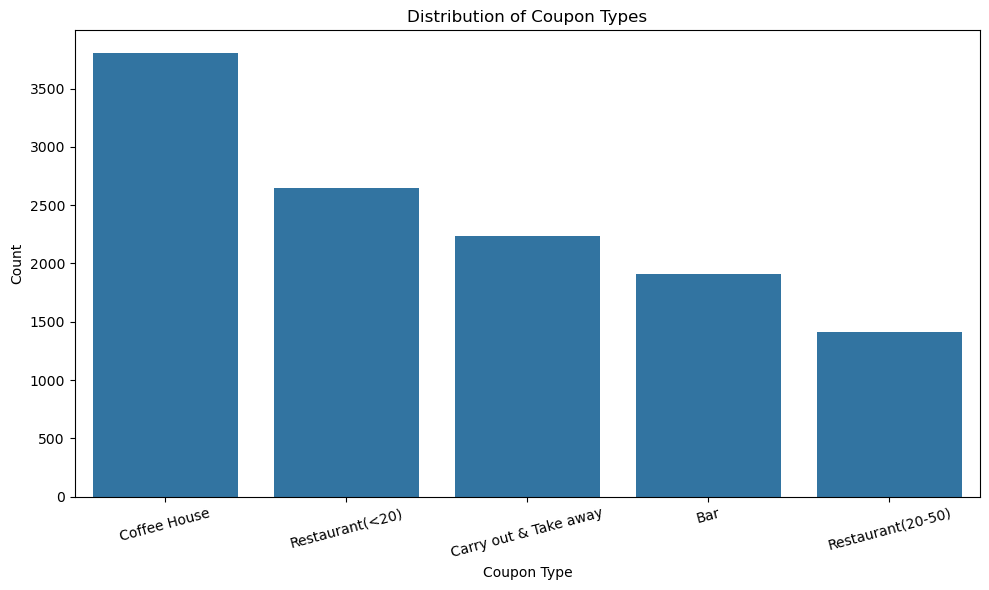

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='coupon', order=data['coupon'].value_counts().index)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

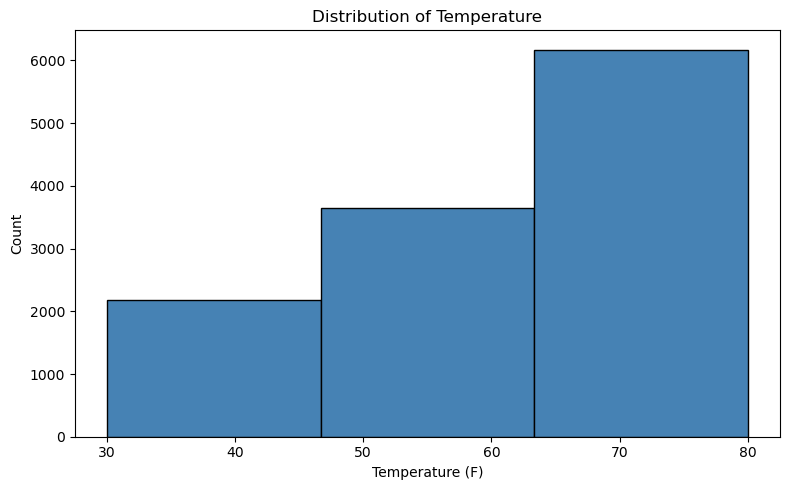

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(data['temperature'], bins=3, edgecolor='black', color='steelblue')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (F)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

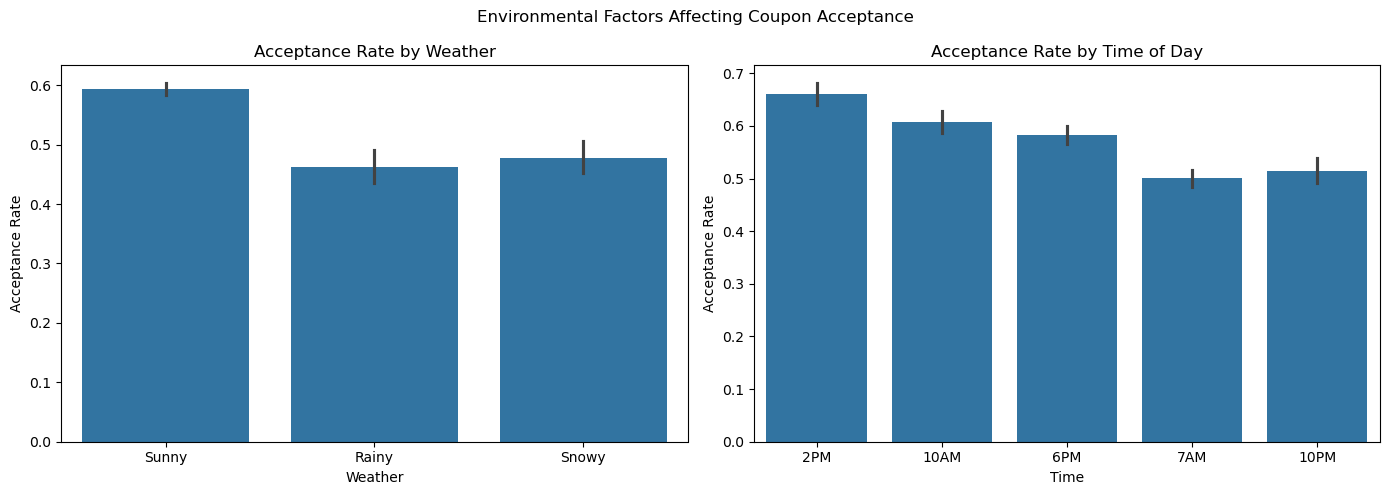

In [22]:
# Subplot comparing acceptance rate by weather and time
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weather
sns.barplot(data=data, x='weather', y='Y', ax=axes[0])
axes[0].set_title('Acceptance Rate by Weather')
axes[0].set_xlabel('Weather')
axes[0].set_ylabel('Acceptance Rate')

# Time
sns.barplot(data=data, x='time', y='Y', ax=axes[1])
axes[1].set_title('Acceptance Rate by Time of Day')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Acceptance Rate')

plt.suptitle('Environmental Factors Affecting Coupon Acceptance')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [23]:
# Filter only bar coupons
bar_data = data[data['coupon'] == 'Bar']
print("Bar coupon shape:", bar_data.shape)

Bar coupon shape: (1906, 25)


2. What proportion of bar coupons were accepted?


In [24]:
# Proportion of bar coupons accepted
bar_acceptance = bar_data['Y'].mean() * 100
print(f"Bar coupon acceptance rate: {bar_acceptance:.2f}%")

Bar coupon acceptance rate: 41.19%


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [25]:
# Split into two groups
low_bar = bar_data[bar_data['Bar'].isin(['never', 'less1', '1~3'])]
high_bar = bar_data[bar_data['Bar'].isin(['4~8', 'gt8'])]

# Calculate acceptance rates
low_bar_rate = low_bar['Y'].mean() * 100
high_bar_rate = high_bar['Y'].mean() * 100

print(f"Acceptance rate — visits bar 3 or fewer times: {low_bar_rate:.2f}%")
print(f"Acceptance rate — visits bar more than 3 times: {high_bar_rate:.2f}%")

Acceptance rate — visits bar 3 or fewer times: 37.24%
Acceptance rate — visits bar more than 3 times: 76.17%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [26]:
# Group 1 — goes to bar more than once AND over 25
group1 = bar_data[
    (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (bar_data['age'] != 'below21') & 
    (bar_data['age'] != '21')
]

# Group 2 — everyone else
group2 = bar_data[
    ~((bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & 
    (bar_data['age'] != 'below21') & 
    (bar_data['age'] != '21'))
]

rate1 = group1['Y'].mean() * 100
rate2 = group2['Y'].mean() * 100

print(f"Bar goers over 25: {rate1:.2f}%")
print(f"All others: {rate2:.2f}%")

Bar goers over 25: 68.98%
All others: 33.73%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [27]:
# Group 1 — goes to bar more than once AND
# passenger is not a kid AND
# occupation is not farming/fishing/forestry
group1 = bar_data[
    (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_data['passanger'] != 'Kid(s)') &
    (~bar_data['occupation'].isin(['Farming Fishing & Forestry']))
]

# Group 2 — everyone else
group2 = bar_data[
    ~(
        (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) &
        (bar_data['passanger'] != 'Kid(s)') &
        (~bar_data['occupation'].isin(['Farming Fishing & Forestry']))
    )
]

rate1 = group1['Y'].mean() * 100
rate2 = group2['Y'].mean() * 100

print(f"Bar goers, no kids, non-farming: {rate1:.2f}%")
print(f"All others: {rate2:.2f}%")


Bar goers, no kids, non-farming: 70.94%
All others: 29.72%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [28]:
# Group 1 — bar more than once, no kids, not widowed
g1 = bar_data[
    (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_data['passanger'] != 'Kid(s)') &
    (bar_data['maritalStatus'] != 'Widowed')
]

# Group 2 — bar more than once AND under 30
g2 = bar_data[
    (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar_data['age'].isin(['below21', '21', '26']))
]

# Group 3 — cheap restaurants more than 4 times AND income < 50K
g3 = bar_data[
    (bar_data['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar_data['income'].isin([
        'Less than $12500', 
        '$12500 - $24999', 
        '$25000 - $37499', 
        '$37500 - $49999'
    ]))
]

# Combine all three groups
combined = pd.concat([g1, g2, g3]).drop_duplicates()
combined_rate = combined['Y'].mean() * 100

print(f"Group 1 rate: {g1['Y'].mean()*100:.2f}%")
print(f"Group 2 rate: {g2['Y'].mean()*100:.2f}%")
print(f"Group 3 rate: {g3['Y'].mean()*100:.2f}%")
print(f"Combined rate: {combined_rate:.2f}%")

Group 1 rate: 70.94%
Group 2 rate: 71.95%
Group 3 rate: 45.65%
Combined rate: 58.71%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

## Bar Coupon Analysis — Findings

Based on the analysis, drivers who accept 
bar coupons tend to share these characteristics:

1. **Frequent bar visitors** — People who visit 
   bars more than 3 times a month accept at 76% 
   vs 37% for infrequent visitors. Bar habit is 
   the strongest predictor.

2. **No kids in the car** — Having kids reduces 
   acceptance significantly. Social, adult focused 
   trips are more likely to result in acceptance.

3. **Age over 25** — Older frequent bar goers 
   accept at 69% vs 34% for others.

4. **Not widowed** — Marital status plays a role,
   likely reflecting social lifestyle differences.

5. **Low income alone is not enough** — Group 3 
   shows that cheap restaurant habits and low 
   income without bar going behavior only yields 
   45% acceptance.

**Conclusion:** The ideal bar coupon target is a 
frequent bar goer, traveling without kids, 
between 25-30 years old, with an active 
social lifestyle.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

## Independent Investigation — Coffee House Coupons
Exploring characteristics of customers who 
accept Coffee House coupons

In [29]:
# Filter coffee house coupons
coffee_data = data[data['coupon'] == 'Coffee House']
print("Coffee House coupon shape:", coffee_data.shape)

Coffee House coupon shape: (3809, 25)


In [30]:
# Overall coffee house acceptance rate
coffee_acceptance = coffee_data['Y'].mean() * 100
print(f"Coffee House acceptance rate: {coffee_acceptance:.2f}%")

Coffee House acceptance rate: 49.57%


Acceptance rate by coffee house visit frequency:
CoffeeHouse
1~3      64.73
4~8      68.24
gt8      65.79
less1    47.95
never    17.52
Name: Y, dtype: float64


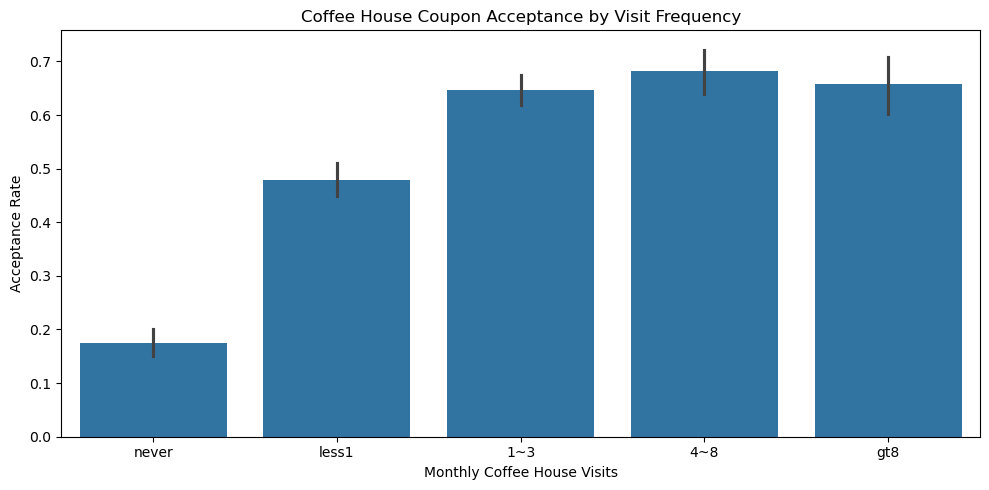

In [31]:
# Acceptance rate by how often they visit coffee houses
coffee_freq = coffee_data.groupby('CoffeeHouse')['Y'].mean() * 100
print("Acceptance rate by coffee house visit frequency:")
print(coffee_freq.round(2))

# Visualize it
plt.figure(figsize=(10, 5))
order = ['never', 'less1', '1~3', '4~8', 'gt8']
sns.barplot(data=coffee_data, x='CoffeeHouse', y='Y', order=order)
plt.title('Coffee House Coupon Acceptance by Visit Frequency')
plt.xlabel('Monthly Coffee House Visits')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()

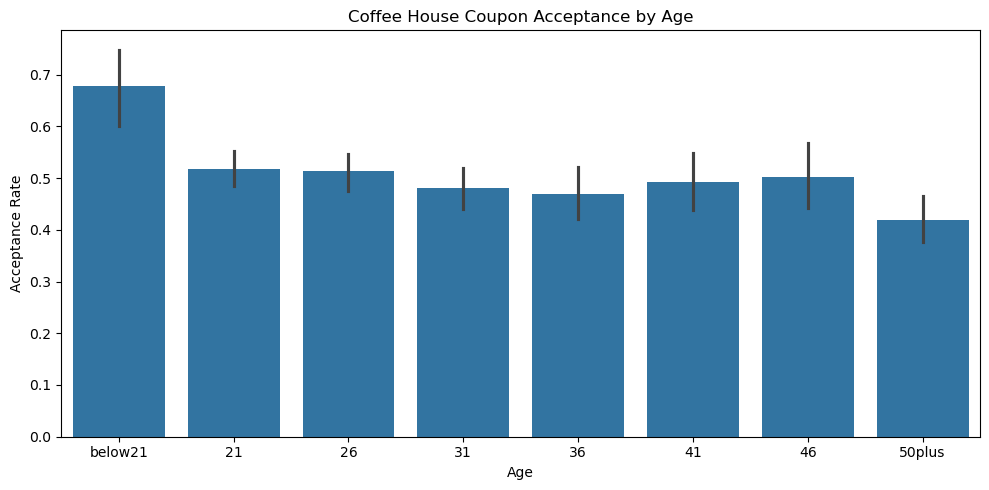

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=coffee_data, x='age', y='Y',
            order=['below21', '21', '26', '31', '36', '41', '46', '50plus'])
plt.title('Coffee House Coupon Acceptance by Age')
plt.xlabel('Age')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()

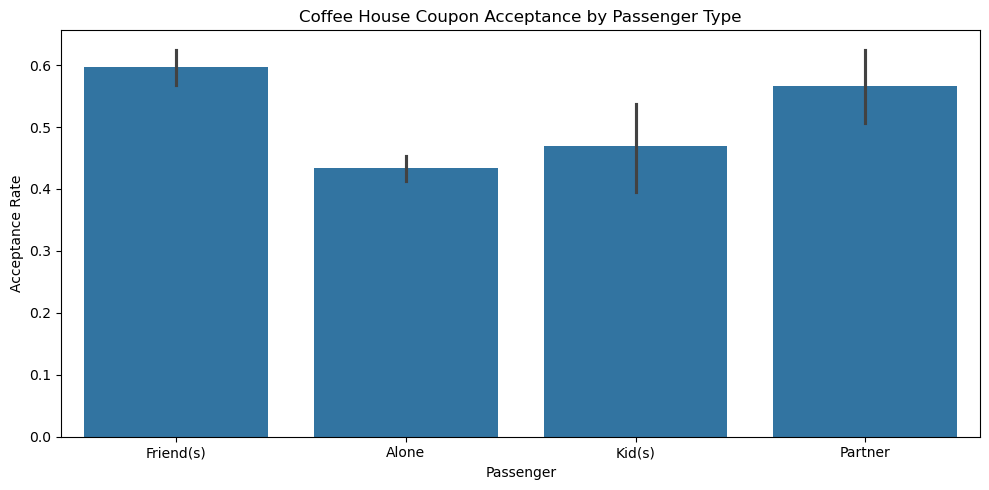

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(data=coffee_data, x='passanger', y='Y')
plt.title('Coffee House Coupon Acceptance by Passenger Type')
plt.xlabel('Passenger')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()

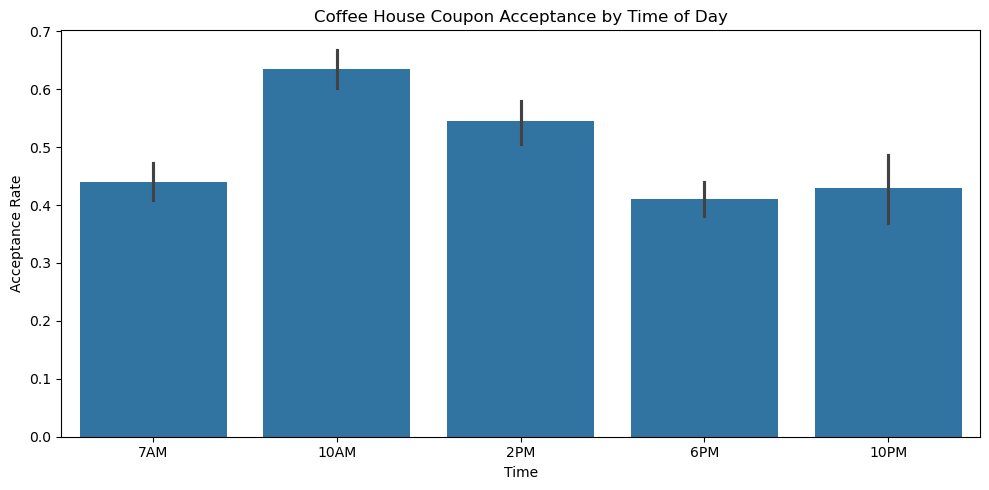

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(data=coffee_data, x='time', y='Y',
            order=['7AM', '10AM', '2PM', '6PM', '10PM'])
plt.title('Coffee House Coupon Acceptance by Time of Day')
plt.xlabel('Time')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()

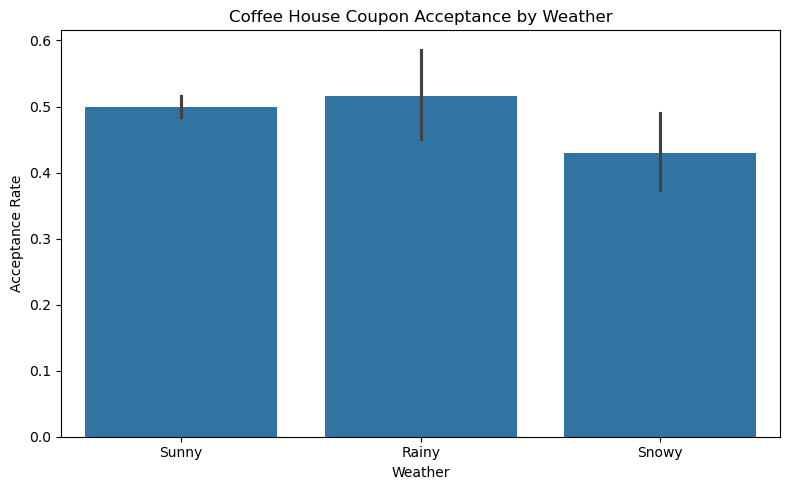

In [35]:
plt.figure(figsize=(8, 5))
sns.barplot(data=coffee_data, x='weather', y='Y')
plt.title('Coffee House Coupon Acceptance by Weather')
plt.xlabel('Weather')
plt.ylabel('Acceptance Rate')
plt.tight_layout()
plt.show()

## Coffee House Coupon — Independent Investigation

### Key Findings:

1. **Overall acceptance rate: 49.57%**
   Slightly below the overall average of 56.84%

2. **Visit frequency is the strongest predictor**
   - Never visit coffee houses → only 17.52% acceptance
   - Visit 4-8 times monthly → 68.24% acceptance
   - Frequent visitors are 4x more likely to accept!

3. **Younger people accept more**
   - Below 21 has the highest acceptance rate
   - Students and young adults love coffee discounts

4. **Social context matters**
   - Traveling with friends → highest acceptance
   - Social mood makes people more open to detours

5. **Timing is everything**
   - 10AM has highest acceptance
   - Morning coffee culture drives acceptance

6. **Weather plays a role**
   - Rainy weather → highest acceptance
   - People crave warm coffee on cold rainy days

### Conclusion & Recommendations:

The ideal Coffee House coupon target is:
- A frequent coffee house visitor
- Under 21 or young adult
- Traveling with friends
- Coupon delivered around 10AM
- On a rainy day

**Actionable recommendation:** 
Target coffee house coupons at young frequent 
visitors during morning hours and rainy weather 
for maximum acceptance rates.
```

### Next Steps
- Build a predictive ML model to classify 
  coupon acceptance
- Analyze remaining coupon types
- Investigate combinations of variables together